# Importación de librerías

In [1]:
from tqdm import tqdm
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import filters_and_features as ff
import data_processor as dp
import numpy as np
from sklearn.decomposition import PCA

# Importación de datos

In [2]:
df = dp.lectura(mode=1)
df_val = dp.lectura(mode=2)

Se crea el dataframe df_block

In [3]:
df_block = dp.create_df_block(df)
df_block_val = dp.create_df_block(df_val)

In [4]:
del df
del df_val

Se limpia y visualiza el contenido

In [5]:
dp.balance(df_block)
dp.balance(df_block_val)
print(df_block['stimulus'].value_counts())
print(df_block_val['stimulus'].value_counts())

stimulus
1     216
0     216
3     216
4     216
6     216
9     216
10    216
11    216
Name: count, dtype: int64
stimulus
1     24
0     24
3     24
4     24
6     24
9     24
10    24
11    24
Name: count, dtype: int64


# Filtro

In [6]:
df_block_filtered = dp.filtrar(df_block)
df_block_filtered_val = dp.filtrar(df_block_val)

Procesando: 100%|██████████| 3/3 [00:15<00:00,  5.11s/it]


In [7]:
del df_block
del df_block_val

# Extracción de características

In [8]:
df_block_features = dp.gen_carac(df_block_filtered)
df_block_features_val = dp.gen_carac(df_block_filtered_val)

Extrayendo Características:  89%|████████▉ | 1536/1728 [02:09<00:16, 11.99it/s]c:\Users\ASUS\Downloads\Proyecto PDSI\PDSI-EMG\src\filters_and_features.py:189: RuntimeWarning: invalid value encountered in scalar divide
  frecuencia_media = np.sum(xf * espectro) / np.sum(espectro)
Extrayendo Características:  89%|████████▉ | 1538/1728 [02:09<00:15, 12.14it/s]c:\Users\ASUS\Downloads\Proyecto PDSI\PDSI-EMG\src\filters_and_features.py:189: RuntimeWarning: invalid value encountered in scalar divide
  frecuencia_media = np.sum(xf * espectro) / np.sum(espectro)
c:\Users\ASUS\Downloads\Proyecto PDSI\PDSI-EMG\src\filters_and_features.py:189: RuntimeWarning: invalid value encountered in scalar divide
  frecuencia_media = np.sum(xf * espectro) / np.sum(espectro)
Extrayendo Características:  89%|████████▉ | 1540/1728 [02:09<00:16, 11.29it/s]c:\Users\ASUS\Downloads\Proyecto PDSI\PDSI-EMG\src\filters_and_features.py:189: RuntimeWarning: invalid value encountered in scalar divide
  frecuencia_media = 

In [9]:
del df_block_filtered
del df_block_filtered_val

In [10]:
df_block_features.describe()

,rms_1,iemg_1,mav_1,wl_1,log_detec_1,ssi_1,fft_1,psd_1,mf_1,mdf_1,...,mav_14,wl_14,log_detec_14,ssi_14,fft_14,psd_14,mf_14,mdf_14,zc_14,stimulus
count,1728.000000,1.728000e+03,1728.000000,1728.000000,1728.000000,1.728000e+03,1728.000000,1.728000e+03,1728.000000,1728.000000,...,1.728000e+03,1728.000000,1.728000e+03,1.728000e+03,1728.000000,1.728000e+03,1728.000000,1728.000000,1728.000000,1728.000000
mean,0.000043,-7.869754e-08,0.000025,0.116543,0.000011,1.562379e-08,0.002261,3.453927e-12,210.138553,75.068866,...,2.291968e-06,0.009168,1.303809e-06,7.189582e-10,0.000178,1.766150e-13,225.517099,82.556713,1859.730903,5.500000
std,0.000038,1.180114e-06,0.000022,0.072946,0.000010,6.982708e-08,0.001641,1.525762e-11,26.240863,19.499392,...,3.943913e-06,0.011773,1.735491e-06,2.080911e-08,0.000390,5.362732e-12,40.392508,34.998622,496.196996,3.906255
min,0.000005,-1.358411e-05,0.000004,0.015201,0.000002,1.393752e-10,0.000296,2.744375e-14,112.690301,12.000000,...,1.309322e-08,0.000071,6.270535e-09,1.980688e-15,0.000001,5.581636e-19,97.554654,13.000000,515.000000,0.000000
25%,0.000025,-1.405283e-07,0.000015,0.071018,0.000007,2.925400e-09,0.001377,6.535966e-13,193.998075,65.000000,...,5.587381e-08,0.000402,3.683207e-08,2.442991e-14,0.000005,5.156584e-18,184.823387,46.000000,1439.750000,2.500000
50%,0.000034,3.045479e-08,0.000020,0.100764,0.000009,5.521249e-09,0.001891,1.202803e-12,208.890573,75.000000,...,8.616777e-08,0.000638,5.846507e-08,5.541042e-14,0.000007,1.149167e-17,252.058130,110.000000,1847.000000,5.000000
75%,0.000047,1.889845e-07,0.000027,0.140396,0.000012,1.037171e-08,0.002554,2.227057e-12,226.223567,87.000000,...,3.965092e-06,0.017233,2.412085e-06,1.514661e-10,0.000294,3.268191e-14,256.789908,114.000000,2343.000000,9.250000
max,0.000690,1.258431e-05,0.000361,0.734268,0.000143,2.414353e-06,0.025327,5.133014e-10,295.225312,127.000000,...,9.765064e-05,0.150995,1.735379e-05,8.629341e-07,0.012427,2.225473e-10,294.122330,126.000000,2757.000000,11.000000


In [11]:
df_block_features_val.describe()

,rms_1,iemg_1,mav_1,wl_1,log_detec_1,ssi_1,fft_1,psd_1,mf_1,mdf_1,...,mav_14,wl_14,log_detec_14,ssi_14,fft_14,psd_14,mf_14,mdf_14,zc_14,stimulus
count,192.000000,1.920000e+02,192.000000,192.000000,192.000000,1.920000e+02,192.000000,1.920000e+02,192.000000,192.000000,...,1.920000e+02,192.000000,1.920000e+02,1.920000e+02,192.000000,1.920000e+02,192.000000,192.000000,192.000000,192.000000
mean,0.000038,1.150428e-07,0.000024,0.118714,0.000011,8.554463e-09,0.002023,1.853641e-12,197.465951,70.078125,...,6.251820e-08,0.000458,4.135757e-08,3.143998e-14,0.000005,6.592443e-18,256.731139,113.203125,2361.921875,5.500000
std,0.000019,2.446042e-07,0.000012,0.070314,0.000005,9.493439e-09,0.001063,1.974233e-12,12.558370,9.631924,...,1.408404e-08,0.000116,9.755958e-09,1.363202e-14,0.000001,2.746407e-18,4.212336,2.341385,240.618681,3.915334
min,0.000011,-8.465761e-07,0.000008,0.032802,0.000004,5.952242e-10,0.000609,1.299651e-13,163.544526,44.000000,...,3.830642e-08,0.000215,2.381773e-08,1.002191e-14,0.000003,2.674812e-18,246.988356,102.000000,1648.000000,0.000000
25%,0.000023,-1.869083e-08,0.000015,0.073572,0.000008,2.422339e-09,0.001237,5.277885e-13,190.129140,64.000000,...,5.027086e-08,0.000355,3.299444e-08,1.910650e-14,0.000004,4.083459e-18,253.886474,112.000000,2283.250000,2.500000
50%,0.000035,7.607904e-08,0.000022,0.097993,0.000010,5.825745e-09,0.001870,1.301860e-12,197.179767,69.000000,...,6.224915e-08,0.000461,4.138923e-08,2.940920e-14,0.000005,6.185178e-18,256.237805,113.000000,2395.500000,5.000000
75%,0.000048,2.133713e-07,0.000030,0.145254,0.000014,1.046504e-08,0.002455,2.312789e-12,204.868440,75.000000,...,7.315252e-08,0.000539,4.776343e-08,4.068897e-14,0.000006,8.769357e-18,258.975595,115.000000,2557.000000,9.250000
max,0.000108,1.250721e-06,0.000068,0.411583,0.000029,5.849259e-08,0.006130,1.209461e-11,232.951644,99.000000,...,9.213208e-08,0.000720,6.277610e-08,6.593552e-14,0.000007,1.306982e-17,268.634822,120.000000,2654.000000,11.000000


# Normalización

In [12]:
df_block_normalized = dp.normalizar(df_block_features)
df_block_normalized_val = dp.normalizar(df_block_features_val)

In [13]:
del df_block_features
del df_block_features_val

In [14]:
df_block_normalized.describe()

,rms_1,iemg_1,mav_1,wl_1,log_detec_1,ssi_1,fft_1,psd_1,mf_1,mdf_1,...,mav_14,wl_14,log_detec_14,ssi_14,fft_14,psd_14,mf_14,mdf_14,zc_14,stimulus
count,1.728000e+03,1.728000e+03,1.728000e+03,1.728000e+03,1.728000e+03,1.728000e+03,1.728000e+03,1.728000e+03,1.728000e+03,1.728000e+03,...,1.728000e+03,1.728000e+03,1728.000000,1.728000e+03,1.728000e+03,1.728000e+03,1.728000e+03,1.728000e+03,1.728000e+03,1728.000000
mean,8.223874e-18,-8.223874e-18,8.223874e-17,1.274701e-16,1.151342e-16,-2.467162e-17,8.223874e-17,-1.644775e-17,1.973730e-16,-3.618505e-16,...,-1.973730e-16,1.315820e-16,0.000000,-1.439178e-17,-3.289550e-17,-6.167906e-18,5.921189e-16,6.579099e-17,-1.315820e-16,5.500000
std,1.000289e+00,1.000289e+00,1.000289e+00,1.000289e+00,1.000289e+00,1.000289e+00,1.000289e+00,1.000289e+00,1.000289e+00,1.000289e+00,...,1.000289e+00,1.000289e+00,1.000289,1.000289e+00,1.000289e+00,1.000289e+00,1.000289e+00,1.000289e+00,1.000289e+00,3.906255
min,-9.827005e-01,-1.144747e+01,-9.632313e-01,-1.389682e+00,-8.514993e-01,-2.218178e-01,-1.197311e+00,-2.246403e-01,-3.714682e+00,-3.235338e+00,...,-5.779880e-01,-7.729815e-01,-0.747866,-3.456008e-02,-4.531777e-01,-3.294320e-02,-3.168892e+00,-1.987988e+00,-2.710859e+00,0.000000
25%,-4.596512e-01,-5.240909e-02,-4.607291e-01,-6.242859e-01,-4.367852e-01,-1.819074e-01,-5.385694e-01,-1.835897e-01,-6.152675e-01,-5.165177e-01,...,-5.671376e-01,-7.448844e-01,-0.730251,-3.455900e-02,-4.448742e-01,-3.294234e-02,-1.007749e+00,-1.044821e+00,-8.466445e-01,2.500000
50%,-2.216166e-01,9.251984e-02,-2.189747e-01,-2.163749e-01,-2.331228e-01,-1.447212e-01,-2.254961e-01,-1.475837e-01,-4.757243e-02,-3.532709e-03,...,-5.594542e-01,-7.248002e-01,-0.717782,-3.455751e-02,-4.391688e-01,-3.294116e-02,6.572683e-01,7.843518e-01,-2.566438e-02,5.000000
75%,1.012320e-01,2.268930e-01,9.513228e-02,3.270827e-01,7.703462e-02,-7.523726e-02,1.782851e-01,-8.043361e-02,6.131533e-01,6.120492e-01,...,4.243522e-01,6.852093e-01,0.638780,-2.727923e-02,2.984689e-01,-2.684727e-02,7.744471e-01,8.986751e-01,9.742280e-01,9.250000
max,1.697822e+01,1.073344e+01,1.549631e+01,8.470723e+00,1.261860e+01,3.436236e+01,1.405554e+01,3.342561e+01,3.243468e+00,2.663989e+00,...,2.418569e+01,1.205049e+01,9.250768,4.144650e+01,3.141783e+01,4.147794e+01,1.698956e+00,1.241645e+00,1.808816e+00,11.000000


In [15]:
df_block_normalized_val.describe()

,rms_1,iemg_1,mav_1,wl_1,log_detec_1,ssi_1,fft_1,psd_1,mf_1,mdf_1,...,mav_14,wl_14,log_detec_14,ssi_14,fft_14,psd_14,mf_14,mdf_14,zc_14,stimulus
count,192.000000,1.920000e+02,1.920000e+02,1.920000e+02,1.920000e+02,1.920000e+02,1.920000e+02,1.920000e+02,1.920000e+02,192.000000,...,1.920000e+02,1.920000e+02,1.920000e+02,1.920000e+02,1.920000e+02,1.920000e+02,1.920000e+02,1.920000e+02,1.920000e+02,192.000000
mean,0.000000,1.850372e-17,-3.700743e-17,-3.700743e-17,7.401487e-17,3.700743e-17,-3.700743e-17,1.850372e-16,6.337523e-16,0.000000,...,-5.366078e-16,-1.110223e-16,6.661338e-16,5.551115e-17,4.625929e-16,-1.295260e-16,-1.029732e-14,9.251859e-18,-1.850372e-17,5.500000
std,1.002614,1.002614e+00,1.002614e+00,1.002614e+00,1.002614e+00,1.002614e+00,1.002614e+00,1.002614e+00,1.002614e+00,1.002614,...,1.002614e+00,1.002614e+00,1.002614e+00,1.002614e+00,1.002614e+00,1.002614e+00,1.002614e+00,1.002614e+00,1.002614e+00,3.915334
min,-1.373485,-3.941605e+00,-1.368213e+00,-1.225027e+00,-1.421303e+00,-8.405855e-01,-1.333382e+00,-8.753689e-01,-2.708163e+00,-2.714546,...,-1.723588e+00,-2.109449e+00,-1.802559e+00,-1.575267e+00,-1.902533e+00,-1.430186e+00,-2.318964e+00,-4.797337e+00,-2.974783e+00,0.000000
25%,-0.780766,-5.481642e-01,-7.439592e-01,-6.436816e-01,-7.530011e-01,-6.476216e-01,-7.417805e-01,-6.733343e-01,-5.857442e-01,-0.632689,...,-8.718637e-01,-8.950344e-01,-8.594745e-01,-9.071091e-01,-8.863442e-01,-9.159396e-01,-6.770832e-01,-5.151952e-01,-3.278114e-01,2.500000
50%,-0.130634,-1.597095e-01,-1.816862e-01,-2.954552e-01,-2.073840e-01,-2.881835e-01,-1.449928e-01,-2.802222e-01,-2.284788e-02,-0.112225,...,-1.915338e-02,2.302842e-02,3.254036e-03,-1.493610e-01,-6.798023e-02,-1.486776e-01,-1.174225e-01,-8.698101e-02,1.399140e-01,5.000000
75%,0.505088,4.030414e-01,4.640470e-01,3.784274e-01,5.404314e-01,2.017782e-01,4.067901e-01,2.331781e-01,5.909877e-01,0.512332,...,7.570364e-01,6.999712e-01,6.583270e-01,6.802489e-01,7.442133e-01,7.947130e-01,5.342225e-01,7.694474e-01,8.128551e-01,9.250000
max,3.624626,4.655062e+00,3.562573e+00,4.176022e+00,3.512316e+00,5.274031e+00,3.872480e+00,5.200877e+00,2.833048e+00,3.010560,...,2.108153e+00,2.273547e+00,2.201170e+00,2.537095e+00,2.193453e+00,2.364656e+00,2.833298e+00,2.910518e+00,1.217037e+00,11.000000


# Creación de dataframes de entrenamiento y testeo

In [16]:
y = df_block_normalized.iloc[:, -1]
X = df_block_normalized.iloc[:, :-1]
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    random_state=100,
                                                    test_size=0.30,
                                                    shuffle=True)

In [17]:
y_val = df_block_normalized_val.iloc[:, -1]
X_val = df_block_normalized_val.iloc[:, :-1]

In [18]:
del df_block_normalized
del df_block_normalized_val

In [19]:
print(X_train.shape,y_train.shape)
print(X_val.shape,y_val.shape)

(1209, 154) (1209,)
(192, 154) (192,)


# Entrenamiento y testeo del modelo

Importamos librerías

In [25]:
# Random forest
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Rotation forest
from sktime.classification.sklearn import RotationForest
from sktime.datasets import load_unit_test
from sktime.datatypes._panel._convert import from_nested_to_3d_numpy

# Artificial Neural Networks (ANN)
import setuptools.dist
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder

In [21]:
# Visualization libraries

import seaborn as sns

Random forest

In [22]:
rf = RandomForestClassifier(
    max_depth=20,             # Profundidad máxima de los árboles
    criterion='entropy',      # Criterio de medida para la calidad de la división ('entropy' o 'gini')
    min_samples_split=4,      # Número mínimo de muestras requeridas para dividir un nodo
    random_state=99,          # Para reproducibilidad del modelo
    n_estimators=3000,        # Número de árboles en el bosque
    verbose=0,                # Imprimir información durante el entrenamiento
    oob_score=True,           # Calcular la precisión del modelo fuera de la bolsa (OOB)
    n_jobs=-1                 # Usar todos los procesadores disponibles para acelerar el entrenamiento
)
rf.fit(X_train, y_train)
y_pred_RanF = rf.predict(X_test)
y_pred_RanF_val = rf.predict(X_val)

Rotation forest

In [23]:
clf = RotationForest(n_estimators=300)
clf.fit(X_train, y_train)
y_pred_RotF = clf.predict(X_test)
y_pred_RotF_val = clf.predict(X_val)

Artificial Neural Networks (ANN)

In [26]:
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)  # Transforma las etiquetas a valores consecutivos (0 a 7)
y_test_enc = le.transform(y_test)

# Asegurarse de que el número de clases sea correcto
num_classes = len(np.unique(y_train_enc))
print("Número de clases detectadas en y_train_b:", num_classes)  # Esto debería ser 8

# Convertir a formato categórico
y_train_cat = to_categorical(y_train_enc, num_classes=num_classes)
y_test_cat = to_categorical(y_test_enc, num_classes=num_classes)

# Definir y entrenar la red neuronal
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

model = Sequential([
    Dense(256, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(num_classes, activation='softmax')  # La capa de salida ahora usa 8 neuronas, una por clase
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.fit(X_train, y_train_cat, epochs=50, batch_size=32, validation_split=0.2, verbose=0)

# Predicción y decodificación
y_pred_probs = model.predict(X_test)
y_pred_ann_e = np.argmax(y_pred_probs, axis=1)
y_pred_ann = le.inverse_transform(y_pred_ann_e)  # Convertir a las etiquetas originales

# Predicción y decodificación
y_pred_probs_val = model.predict(X_val)
y_pred_ann_e_val = np.argmax(y_pred_probs_val, axis=1)
y_pred_ann_val = le.inverse_transform(y_pred_ann_e_val)  # Convertir a las etiquetas originales

Número de clases detectadas en y_train_b: 8


c:\Users\ASUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


# Resultados

Random forest

Test data

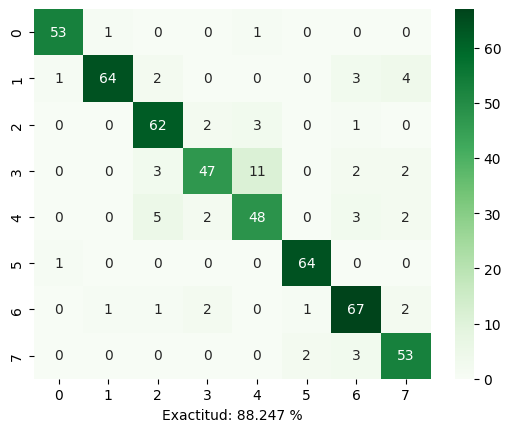

              precision    recall  f1-score   support

           0       0.96      0.96      0.96        55
           1       0.97      0.86      0.91        74
           3       0.85      0.91      0.88        68
           4       0.89      0.72      0.80        65
           6       0.76      0.80      0.78        60
           9       0.96      0.98      0.97        65
          10       0.85      0.91      0.88        74
          11       0.84      0.91      0.88        58

    accuracy                           0.88       519
   macro avg       0.88      0.88      0.88       519
weighted avg       0.89      0.88      0.88       519



In [27]:
sns.heatmap(confusion_matrix(y_pred_RanF, y_test),cmap="Greens",annot=True)
plt.xlabel(f'Exactitud: {round(100*accuracy_score(y_pred_RanF, y_test),3)} %')
plt.show()
print(classification_report(y_pred_RanF, y_test))

Validation data

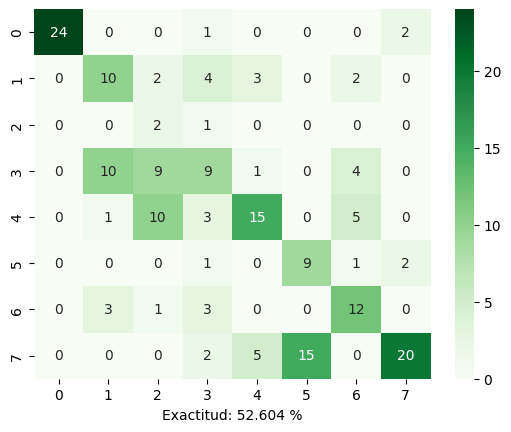

              precision    recall  f1-score   support

           0       1.00      0.89      0.94        27
           1       0.42      0.48      0.44        21
           3       0.08      0.67      0.15         3
           4       0.38      0.27      0.32        33
           6       0.62      0.44      0.52        34
           9       0.38      0.69      0.49        13
          10       0.50      0.63      0.56        19
          11       0.83      0.48      0.61        42

    accuracy                           0.53       192
   macro avg       0.53      0.57      0.50       192
weighted avg       0.62      0.53      0.55       192



In [28]:
sns.heatmap(confusion_matrix(y_pred_RanF_val, y_val),cmap="Greens",annot=True)
plt.xlabel(f'Exactitud: {round(100*accuracy_score(y_pred_RanF_val, y_val),3)} %')
plt.show()
print(classification_report(y_pred_RanF_val, y_val))

Rotation forest

Test data

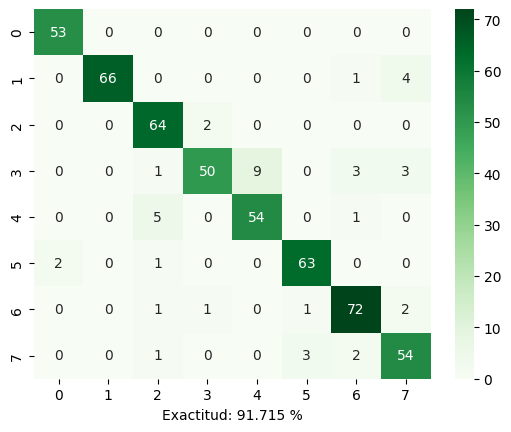

              precision    recall  f1-score   support

           0       0.96      1.00      0.98        53
           1       1.00      0.93      0.96        71
           3       0.88      0.97      0.92        66
           4       0.94      0.76      0.84        66
           6       0.86      0.90      0.88        60
           9       0.94      0.95      0.95        66
          10       0.91      0.94      0.92        77
          11       0.86      0.90      0.88        60

    accuracy                           0.92       519
   macro avg       0.92      0.92      0.92       519
weighted avg       0.92      0.92      0.92       519



In [29]:
sns.heatmap(confusion_matrix(y_pred_RotF, y_test),cmap="Greens",annot=True)
plt.xlabel(f'Exactitud: {round(100*accuracy_score(y_pred_RotF, y_test),3)} %')
plt.show()
print(classification_report(y_pred_RotF, y_test))

Validation data

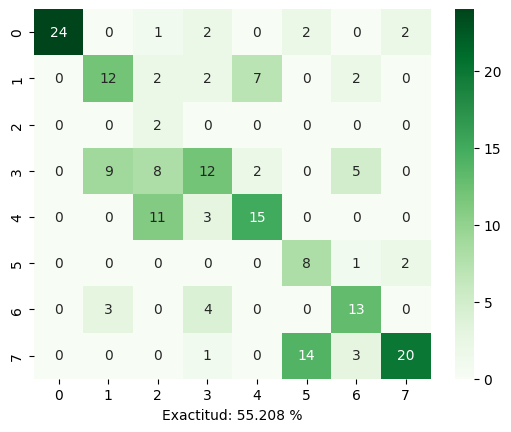

              precision    recall  f1-score   support

           0       1.00      0.77      0.87        31
           1       0.50      0.48      0.49        25
           3       0.08      1.00      0.15         2
           4       0.50      0.33      0.40        36
           6       0.62      0.52      0.57        29
           9       0.33      0.73      0.46        11
          10       0.54      0.65      0.59        20
          11       0.83      0.53      0.65        38

    accuracy                           0.55       192
   macro avg       0.55      0.63      0.52       192
weighted avg       0.66      0.55      0.58       192



In [30]:
sns.heatmap(confusion_matrix(y_pred_RotF_val, y_val),cmap="Greens",annot=True)
plt.xlabel(f'Exactitud: {round(100*accuracy_score(y_pred_RotF_val, y_val),3)} %')
plt.show()
print(classification_report(y_pred_RotF_val, y_val))

Artificial Neural Networks (ANN)

Test data

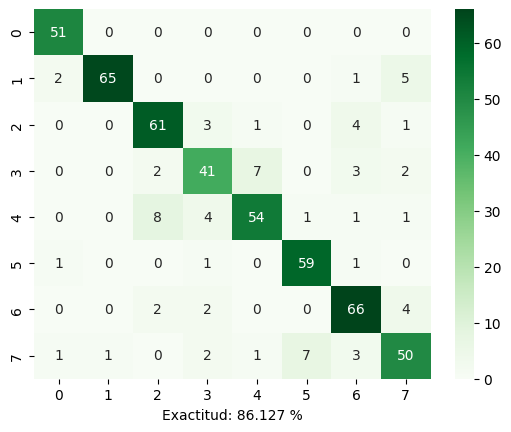

              precision    recall  f1-score   support

           0       0.93      1.00      0.96        51
           1       0.98      0.89      0.94        73
           3       0.84      0.87      0.85        70
           4       0.77      0.75      0.76        55
           6       0.86      0.78      0.82        69
           9       0.88      0.95      0.91        62
          10       0.84      0.89      0.86        74
          11       0.79      0.77      0.78        65

    accuracy                           0.86       519
   macro avg       0.86      0.86      0.86       519
weighted avg       0.86      0.86      0.86       519



In [31]:
sns.heatmap(confusion_matrix(y_pred_ann, y_test),cmap="Greens",annot=True)
plt.xlabel(f'Exactitud: {round(100*accuracy_score(y_pred_ann, y_test),3)} %')
plt.show()
print(classification_report(y_pred_ann, y_test))

Validation data

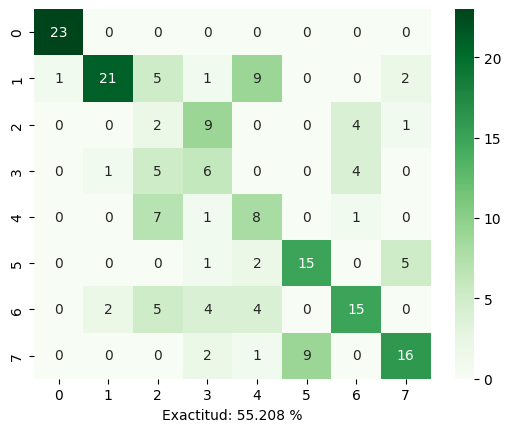

              precision    recall  f1-score   support

           0       0.96      1.00      0.98        23
           1       0.88      0.54      0.67        39
           3       0.08      0.12      0.10        16
           4       0.25      0.38      0.30        16
           6       0.33      0.47      0.39        17
           9       0.62      0.65      0.64        23
          10       0.62      0.50      0.56        30
          11       0.67      0.57      0.62        28

    accuracy                           0.55       192
   macro avg       0.55      0.53      0.53       192
weighted avg       0.62      0.55      0.57       192



In [32]:
sns.heatmap(confusion_matrix(y_pred_ann_val, y_val),cmap="Greens",annot=True)
plt.xlabel(f'Exactitud: {round(100*accuracy_score(y_pred_ann_val, y_val),3)} %')
plt.show()
print(classification_report(y_pred_ann_val, y_val))

# Con PCA

In [49]:
pca = PCA(0.99)
pca_val = PCA(0.9979)

X_pca = pca.fit_transform(X)

X_train_pca, X_test_pca, y_train, y_test = train_test_split(X_pca, y,
                                                    random_state=100,
                                                    test_size=0.30,
                                                    shuffle=True)

X_pca_val = pca_val.fit_transform(X_val)

In [50]:
print('Sin PCA')
print(X.shape)
print(X_pca.shape)
print('Con PCA')
print(X_val.shape)
print(X_pca_val.shape)

Sin PCA
(1728, 154)
(1728, 70)
Con PCA
(192, 154)
(192, 70)


Random forest

In [51]:
rf_pca = RandomForestClassifier(
    max_depth=20,             # Profundidad máxima de los árboles
    criterion='entropy',      # Criterio de medida para la calidad de la división ('entropy' o 'gini')
    min_samples_split=4,      # Número mínimo de muestras requeridas para dividir un nodo
    random_state=99,          # Para reproducibilidad del modelo
    n_estimators=3000,        # Número de árboles en el bosque
    verbose=0,                # Imprimir información durante el entrenamiento
    oob_score=True,           # Calcular la precisión del modelo fuera de la bolsa (OOB)
    n_jobs=-1                 # Usar todos los procesadores disponibles para acelerar el entrenamiento
)
rf_pca.fit(X_train_pca, y_train)
y_pred_RanF_pca = rf_pca.predict(X_test_pca)
y_pred_RanF_pca_val = rf_pca.predict(X_pca_val)

Rotation forest

In [52]:
clf_pca = RotationForest(n_estimators=300)
clf_pca.fit(X_train_pca, y_train)
y_pred_RotF_pca = clf_pca.predict(X_test_pca)
y_pred_RotF_pca_val = clf_pca.predict(X_pca_val)

Artificial Neural Networks (ANN)

In [53]:
le_pca = LabelEncoder()
y_train_enc = le_pca.fit_transform(y_train)  # Transforma las etiquetas a valores consecutivos (0 a 7)
y_test_enc = le_pca.transform(y_test)

# Asegurarse de que el número de clases sea correcto
num_classes = len(np.unique(y_train_enc))
print("Número de clases detectadas en y_train_b:", num_classes)  # Esto debería ser 8

# Convertir a formato categórico
y_train_cat = to_categorical(y_train_enc, num_classes=num_classes)
y_test_cat = to_categorical(y_test_enc, num_classes=num_classes)

# Definir y entrenar la red neuronal
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

model = Sequential([
    Dense(256, activation='relu', input_shape=(X_train_pca.shape[1],)),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(num_classes, activation='softmax')  # La capa de salida ahora usa 8 neuronas, una por clase
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.fit(X_train_pca, y_train_cat, epochs=50, batch_size=32, validation_split=0.2, verbose=0)

# Predicción y decodificación
y_pred_probs = model.predict(X_test_pca)
y_pred_ann_e = np.argmax(y_pred_probs, axis=1)
y_pred_ann_pca = le_pca.inverse_transform(y_pred_ann_e)  # Convertir a las etiquetas originales

# Predicción y decodificación
y_pred_probs_val = model.predict(X_pca_val)
y_pred_ann_e_val = np.argmax(y_pred_probs_val, axis=1)
y_pred_ann_pca_val = le_pca.inverse_transform(y_pred_ann_e_val)  # Convertir a las etiquetas originales

Número de clases detectadas en y_train_b: 8


c:\Users\ASUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


# Resultados

Random forest

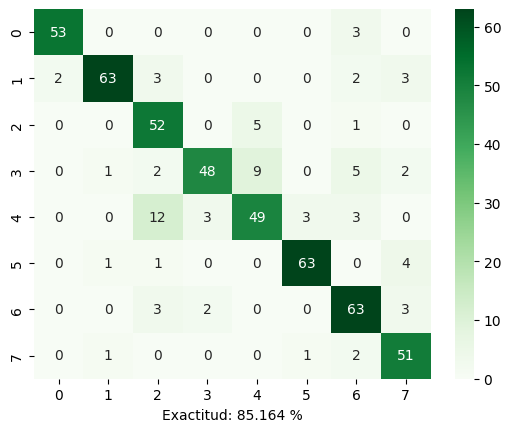

              precision    recall  f1-score   support

           0       0.96      0.95      0.95        56
           1       0.95      0.86      0.91        73
           3       0.71      0.90      0.79        58
           4       0.91      0.72      0.80        67
           6       0.78      0.70      0.74        70
           9       0.94      0.91      0.93        69
          10       0.80      0.89      0.84        71
          11       0.81      0.93      0.86        55

    accuracy                           0.85       519
   macro avg       0.86      0.86      0.85       519
weighted avg       0.86      0.85      0.85       519



In [54]:
sns.heatmap(confusion_matrix(y_pred_RanF_pca, y_test),cmap="Greens",annot=True)
plt.xlabel(f'Exactitud: {round(100*accuracy_score(y_pred_RanF_pca, y_test),3)} %')
plt.show()
print(classification_report(y_pred_RanF_pca, y_test))

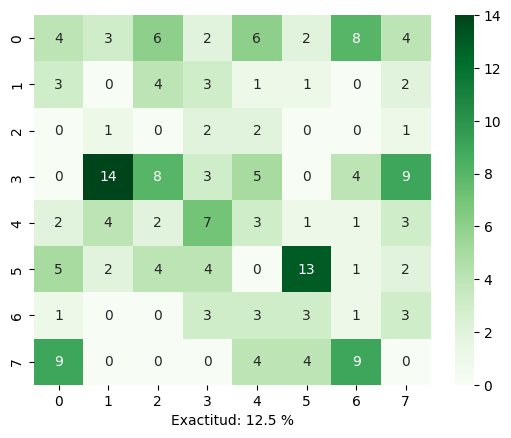

              precision    recall  f1-score   support

           0       0.17      0.11      0.14        35
           1       0.00      0.00      0.00        14
           3       0.00      0.00      0.00         6
           4       0.12      0.07      0.09        43
           6       0.12      0.13      0.13        23
           9       0.54      0.42      0.47        31
          10       0.04      0.07      0.05        14
          11       0.00      0.00      0.00        26

    accuracy                           0.12       192
   macro avg       0.12      0.10      0.11       192
weighted avg       0.16      0.12      0.14       192



In [55]:
sns.heatmap(confusion_matrix(y_pred_RanF_pca_val, y_val),cmap="Greens",annot=True)
plt.xlabel(f'Exactitud: {round(100*accuracy_score(y_pred_RanF_pca_val, y_val),3)} %')
plt.show()
print(classification_report(y_pred_RanF_pca_val, y_val))

Rotation forest

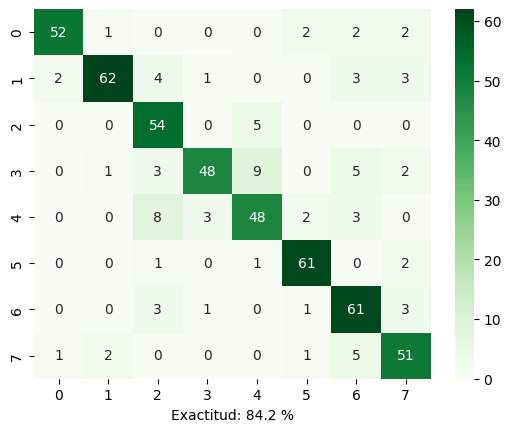

              precision    recall  f1-score   support

           0       0.95      0.88      0.91        59
           1       0.94      0.83      0.88        75
           3       0.74      0.92      0.82        59
           4       0.91      0.71      0.79        68
           6       0.76      0.75      0.76        64
           9       0.91      0.94      0.92        65
          10       0.77      0.88      0.82        69
          11       0.81      0.85      0.83        60

    accuracy                           0.84       519
   macro avg       0.85      0.84      0.84       519
weighted avg       0.85      0.84      0.84       519



In [56]:
sns.heatmap(confusion_matrix(y_pred_RotF_pca, y_test),cmap="Greens",annot=True)
plt.xlabel(f'Exactitud: {round(100*accuracy_score(y_pred_RotF_pca, y_test),3)} %')
plt.show()
print(classification_report(y_pred_RotF_pca, y_test))

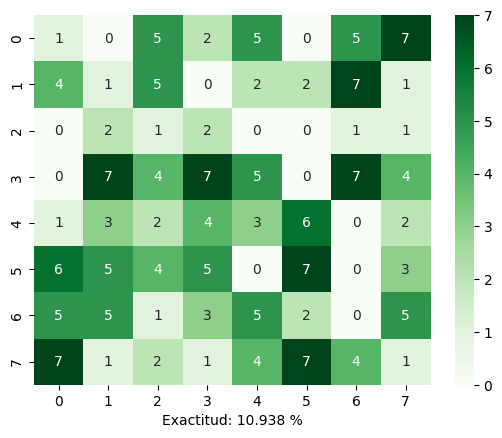

              precision    recall  f1-score   support

           0       0.04      0.04      0.04        25
           1       0.04      0.05      0.04        22
           3       0.04      0.14      0.06         7
           4       0.29      0.21      0.24        34
           6       0.12      0.14      0.13        21
           9       0.29      0.23      0.26        30
          10       0.00      0.00      0.00        26
          11       0.04      0.04      0.04        27

    accuracy                           0.11       192
   macro avg       0.11      0.11      0.10       192
weighted avg       0.13      0.11      0.12       192



In [57]:
sns.heatmap(confusion_matrix(y_pred_RotF_pca_val, y_val),cmap="Greens",annot=True)
plt.xlabel(f'Exactitud: {round(100*accuracy_score(y_pred_RotF_pca_val, y_val),3)} %')
plt.show()
print(classification_report(y_pred_RotF_pca_val, y_val))

Artificial Neural Networks (ANN)

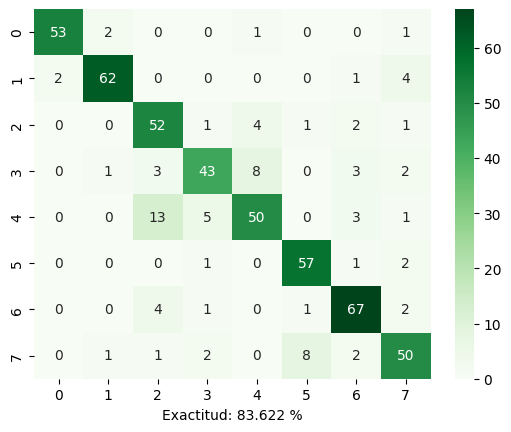

              precision    recall  f1-score   support

           0       0.96      0.93      0.95        57
           1       0.94      0.90      0.92        69
           3       0.71      0.85      0.78        61
           4       0.81      0.72      0.76        60
           6       0.79      0.69      0.74        72
           9       0.85      0.93      0.89        61
          10       0.85      0.89      0.87        75
          11       0.79      0.78      0.79        64

    accuracy                           0.84       519
   macro avg       0.84      0.84      0.84       519
weighted avg       0.84      0.84      0.84       519



In [59]:
sns.heatmap(confusion_matrix(y_pred_ann_pca, y_test),cmap="Greens",annot=True)
plt.xlabel(f'Exactitud: {round(100*accuracy_score(y_pred_ann_pca, y_test),3)} %')
plt.show()
print(classification_report(y_pred_ann_pca, y_test))

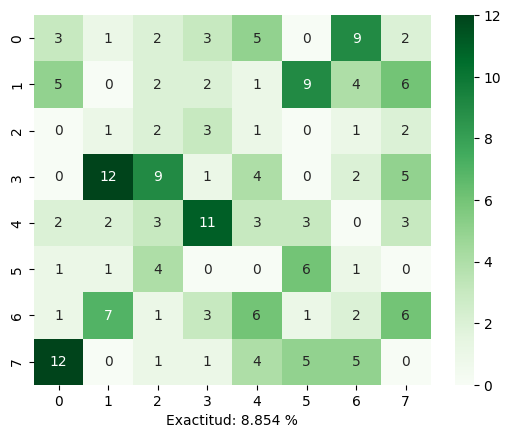

              precision    recall  f1-score   support

           0       0.12      0.12      0.12        25
           1       0.00      0.00      0.00        29
           3       0.08      0.20      0.12        10
           4       0.04      0.03      0.04        33
           6       0.12      0.11      0.12        27
           9       0.25      0.46      0.32        13
          10       0.08      0.07      0.08        27
          11       0.00      0.00      0.00        28

    accuracy                           0.09       192
   macro avg       0.09      0.12      0.10       192
weighted avg       0.07      0.09      0.08       192



In [60]:
sns.heatmap(confusion_matrix(y_pred_ann_pca_val, y_val),cmap="Greens",annot=True)
plt.xlabel(f'Exactitud: {round(100*accuracy_score(y_pred_ann_pca_val, y_val),3)} %')
plt.show()
print(classification_report(y_pred_ann_pca_val, y_val))

Rpoerte de PCA

In [61]:
pca.explained_variance_ratio_

array([0.25578296, 0.09783978, 0.07229469, 0.0636655 , 0.05843025,
       0.04581018, 0.03772325, 0.03553201, 0.0300448 , 0.02036369,
       0.02009768, 0.01777156, 0.01673981, 0.01639061, 0.01354474,
       0.01235988, 0.01059827, 0.00979302, 0.00927859, 0.00836924,
       0.00800836, 0.00729362, 0.00717909, 0.00687393, 0.00638523,
       0.00607648, 0.00589138, 0.00533746, 0.0052387 , 0.00494986,
       0.00475912, 0.00454749, 0.00417377, 0.00386416, 0.00365618,
       0.00365231, 0.00342848, 0.00314006, 0.00297854, 0.00272826,
       0.00255876, 0.00247611, 0.00233852, 0.00219871, 0.00217644,
       0.0020151 , 0.00190627, 0.00170324, 0.00158901, 0.00149304,
       0.00145668, 0.00135359, 0.0012577 , 0.00123459, 0.00117249,
       0.00102016, 0.00096339, 0.00092777, 0.00090259, 0.0008018 ,
       0.00078325, 0.00074968, 0.00069763, 0.00063234, 0.00062683,
       0.00057673, 0.0005563 , 0.00055144, 0.00050615, 0.00049367])